# exp_wda_v2 — Representatividad de la muestra y orden del preprocesamiento (WDA)

Este cuaderno complementa `exp_wda` con dos experimentos de validación metodológica que
no requieren cambiar el pipeline, sino cuantificar dos decisiones que hasta ahora se
habían tomado sin verificación:

| # | Experimento | Pregunta que responde |
|---|-------------|----------------------|
| 1 | **Representatividad de la muestra** | ¿Los resultados valen para la clase WDA, o solo para las 1.100 muestras del `random_state=42`? |
| 2 | **Orden de PCA y estandarización** | ¿Es correcto estandarizar *después* de PCA (whitening), o debería hacerse antes? |

## Contexto del experimento 1

La muestra de trabajo se obtiene con `spectrum_df.sample(n=1100, random_state=42)`: es
aleatoria, pero con semilla fija, de modo que **siempre son los mismos 1.100 espectros**.
Esto garantiza reproducibilidad, pero deja abierta una pregunta: de los 13.723 espectros
WDA disponibles solo se usa un **8%**, y no se sabe si las conclusiones dependen de esa
muestra en particular.

La solución no es quitar la semilla, porque eso destruiría la reproducibilidad sin
demostrar nada. La solución es **repetir el experimento con muchas muestras distintas** y
reportar la variabilidad: si el Silhouette se mantiene estable entre muestras, el
resultado es una propiedad de la clase y no del subconjunto.

## Contexto del experimento 2

El pipeline actual aplica:

```
features crudas  ->  PCA(32)  ->  StandardScaler  ->  clustering
```

Estandarizar *después* de PCA equivale a **whitening**: cada componente principal se
reescala a varianza unitaria, de modo que la primera componente (que puede explicar la
mayor parte de la varianza) y la última (que puede ser casi solo ruido) terminan pesando
lo mismo en la distancia euclidiana sobre la que operan los algoritmos y las métricas.
El experimento 2 contrasta ese orden con las alternativas.

## 0. Setup y carga del pool completo de WDA

Se carga la totalidad de espectros WDA disponibles (13.723) una sola vez, para usarlos
como *pool* del que se extraen las distintas muestras. Los embeddings se extraen también
una sola vez: la red es fija, de modo que el embedding de un espectro no depende de qué
otros espectros lo acompañen en la muestra.

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [22]:
project_dir = Path().resolve().parent

model_path  = os.path.join(project_dir, r"models\model_4C_3FC.h5")
data_path   = os.path.join(project_dir, r"data\raw\sdss_dat_files")
labels_path = os.path.join(project_dir, r"data\raw\label_data")

print(project_dir)

C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF


In [23]:
# etiquetas + indice de archivos .dat (identico a exp_wda)
fields = ['File Name', 'MJD', 'Target ID', 'DB ID', 'Classification', 'Data Quality']
raw_labels_df = pd.DataFrame()

for filename in os.listdir(labels_path):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(labels_path, filename), usecols=fields)
        raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)

file_dict = {}
for folder in os.listdir(data_path):
    folder_full_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_full_path):
        for filename in os.listdir(folder_full_path):
            if filename.endswith('.dat'):
                key = filename.split('-')[-2] + '_' + filename.split('_')[-1]
                file_dict[key] = os.path.join(folder, filename)

print(f"etiquetas: {raw_labels_df.shape[0]} | archivos .dat indexados: {len(file_dict)}")

etiquetas: 35253 | archivos .dat indexados: 33698


In [24]:
full_model = load_model(model_path)
_ = full_model.predict(np.zeros((1, 3750, 1), dtype=np.float32), verbose=0)
print("modelo cargado")

c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


modelo cargado


In [25]:
# ---------- funciones de carga (identicas a exp_wda) ----------

def process_spectrum(file_path):
    try:
        sed  = np.loadtxt(file_path, unpack=True)
        flux = sed[1, 48:-400]

        if len(flux) > 3750:
            start = (len(flux) - 3750) // 2
            flux  = flux[start:start + 3750]
        elif len(flux) < 3750:
            flux = np.pad(flux, (0, 3750 - len(flux)), mode='constant')

        norm_val = flux[2100]
        if norm_val == 0 or np.isnan(norm_val):
            norm_val = np.mean(flux)
        if norm_val == 0 or np.isnan(norm_val):
            return None

        flux = flux / norm_val
        if np.isnan(flux).any():
            return None
        return flux.astype(np.float32)
    except Exception:
        return None


def build_class_dataframe(class_name):
    star_df = raw_labels_df[raw_labels_df['Classification'] == class_name].copy()
    filas = []
    for _, row in star_df.iterrows():
        filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
        if filekey in file_dict:
            filas.append({'filename': file_dict[filekey], 'classID': row['Classification']})
    return pd.DataFrame(filas)


def load_class_spectra(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")
    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}.")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    X_list = []
    for _, row in selected_df.iterrows():
        spec = process_spectrum(os.path.join(data_path, row['filename']))
        if spec is not None:
            X_list.append(spec)

    X_final = np.array(X_list, dtype=np.float32)
    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    print(f"{class_name}: espectros validos finales = {X_input.shape[0]}")
    return X_final, X_input


def build_extractor_until(layer_name, full_model):
    input_layer = layers.Input(shape=(3750, 1))
    x = input_layer
    for layer in full_model.layers:
        x = layer(x)
        if layer.name == layer_name:
            break
    return Model(inputs=input_layer, outputs=x)


flatten_extractor = build_extractor_until("flatten", full_model)
dense_extractor   = build_extractor_until("dense", full_model)
dense1_extractor  = build_extractor_until("dense_1", full_model)
dense2_extractor  = build_extractor_until("dense_2", full_model)


def extract_layer_features(X_input):
    return (flatten_extractor.predict(X_input, batch_size=64, verbose=1),
            dense_extractor.predict(X_input,   batch_size=64, verbose=1),
            dense1_extractor.predict(X_input,  batch_size=64, verbose=1),
            dense2_extractor.predict(X_input,  batch_size=64, verbose=1))

In [26]:
# ---------- metricas (identicas a exp_wda) ----------

def compute_cluster_metrics(Xs, labels):
    mask         = labels != -1
    Xs_clean     = Xs[mask]
    labels_clean = labels[mask]

    n_clusters = len(np.unique(labels_clean))
    n_noise    = int(np.sum(~mask))

    if n_clusters < 2:
        return {"n_clusters": n_clusters, "n_noise": n_noise,
                "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    return {"n_clusters": n_clusters, "n_noise": n_noise,
            "silhouette":        round(silhouette_score(Xs_clean, labels_clean), 6),
            "davies_bouldin":    round(davies_bouldin_score(Xs_clean, labels_clean), 6),
            "calinski_harabasz": round(calinski_harabasz_score(Xs_clean, labels_clean), 4)}


def k_por_eigengap(Xs, n_neighbors=10, n_eigen=10):
    """k sugerido por la heuristica del eigengap sobre el grafo kNN."""
    A = kneighbors_graph(Xs, n_neighbors=n_neighbors, mode="connectivity")
    A = 0.5 * (A + A.T)
    L = csgraph_laplacian(A, normed=True)
    vals = np.sort(np.linalg.eigvalsh(L.toarray()))[:n_eigen]
    gaps = np.diff(vals)
    return int(np.argmax(gaps[1:]) + 2)

In [27]:
# ---------- POOL COMPLETO de WDA (13.723 espectros) ----------
# Este es el paso lento del cuaderno: lee todos los .dat desde disco.
X_pool_spec, X_pool_input = load_class_spectra("WDA", n_samples=13723, random_state=RANDOM_STATE)

f_pool, d_pool, d1_pool, d2_pool = extract_layer_features(X_pool_input)

# features crudas por capa, SIN reducir ni estandarizar (esa es la variable del experimento)
POOL = {"flatten": f_pool, "dense": d_pool, "dense_1": d1_pool, "dense_2": d2_pool}
N_POOL = X_pool_input.shape[0]

print()
for capa, F in POOL.items():
    print(f"  {capa:9} -> {F.shape}")
print(f"\nPool total: {N_POOL} espectros")

WDA: disponibles con match a .dat = 13723
WDA: espectros validos finales = 13711
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

  flatten   -> (13711, 208)
  dense     -> (13711, 128)
  dense_1   -> (13711, 64)
  dense_2   -> (13711, 32)

Pool total: 13711 espectros


## Experimento 1 — Representatividad de la muestra

### Diseño

Se extraen `N_SEMILLAS` muestras distintas de 1.100 espectros desde el pool de 13.723, y
sobre cada una se repite el pipeline completo:

```
muestra de 1100  ->  PCA(32)  ->  StandardScaler  ->  Spectral Clustering  ->  métricas
```

Es importante que **PCA se reajuste en cada muestra**, porque así ocurre en el pipeline
real: el espacio de 32 dimensiones no es fijo, se aprende de los datos disponibles. Si
solo se reutilizara el PCA del pool completo, el experimento subestimaría la variabilidad.

Se registran dos cosas por muestra:

- las **métricas** a un $k$ de referencia fijo, para medir cuánto varía la calidad del
  agrupamiento entre muestras;
- el **$k$ que habría seleccionado el criterio del eigengap**, para verificar si la
  elección del número de clusters es estable o depende de la muestra.

Si el Silhouette resulta, por ejemplo, $0{,}385 \pm 0{,}02$, la afirmación deja de ser
*"en mi muestra dio 0,385"* y pasa a ser *"para la clase WDA da 0,385 ± 0,02"*, que es la
afirmación que la memoria necesita.

In [28]:
def experimento_representatividad(pool, capa, k_ref, n_muestras=1100,
                                  n_semillas=20, semilla_base=42, verbose=True):
    """
    Repite el pipeline sobre n_semillas muestras distintas del pool y devuelve un
    DataFrame con las metricas de cada una.

    pool  : dict {capa: features crudas del pool completo}
    capa  : capa a evaluar
    k_ref : numero de clusters de referencia (el usado en el experimento principal)
    """
    F_pool = pool[capa]
    n_total = F_pool.shape[0]

    filas = []
    for s in range(n_semillas):
        semilla = semilla_base + s
        rng = np.random.default_rng(semilla)
        idx = rng.choice(n_total, size=n_muestras, replace=False)

        F = F_pool[idx]

        # pipeline real: PCA se reajusta en cada muestra
        if F.shape[1] > 32:
            F32 = PCA(n_components=32, random_state=RANDOM_STATE).fit_transform(F)
        else:
            F32 = F.copy()          # dense_2 ya viene en 32
        Xs = StandardScaler().fit_transform(F32)

        labels = SpectralClustering(n_clusters=k_ref, affinity="nearest_neighbors",
                                    assign_labels="kmeans",
                                    random_state=RANDOM_STATE).fit_predict(Xs)
        m = compute_cluster_metrics(Xs, labels)

        filas.append({
            "semilla"           : semilla,
            "capa"              : capa,
            "k_ref"             : k_ref,
            "silhouette"        : m["silhouette"],
            "davies_bouldin"    : m["davies_bouldin"],
            "calinski_harabasz" : m["calinski_harabasz"],
            "k_eigengap"        : k_por_eigengap(Xs)
        })

        if verbose:
            print(f"  semilla {semilla}: sil={m['silhouette']:.4f}  "
                  f"DB={m['davies_bouldin']:.3f}  k_eigengap={filas[-1]['k_eigengap']}")

    return pd.DataFrame(filas)

In [29]:
# Configuracion del experimento
N_SEMILLAS = 20          # subir a 50 si se quiere mayor precision (mas lento)
N_MUESTRAS = 1100        # mismo tamano que el experimento principal

# k de referencia por capa (los usados en exp_wda)
K_REF = {"flatten": 3, "dense": 5, "dense_1": 2, "dense_2": 2}

CAPAS_EVAL = ["flatten", "dense_2"]   # capas de mayor interes; ampliar si se desea

print(f"{N_SEMILLAS} muestras de {N_MUESTRAS} espectros, extraidas de un pool de {N_POOL}")
print(f"cobertura de cada muestra: {100*N_MUESTRAS/N_POOL:.1f}% de la clase")

20 muestras de 1100 espectros, extraidas de un pool de 13711
cobertura de cada muestra: 8.0% de la clase


In [30]:
# Ejecucion del experimento (esta celda tarda algunos minutos)
resultados = []
for capa in CAPAS_EVAL:
    print(f"\n=== capa {capa} (k_ref = {K_REF[capa]}) ===")
    resultados.append(
        experimento_representatividad(POOL, capa, K_REF[capa],
                                      n_muestras=N_MUESTRAS, n_semillas=N_SEMILLAS)
    )

tabla_repr = pd.concat(resultados, ignore_index=True)
print("\nlisto")
display(tabla_repr.head(10))


=== capa flatten (k_ref = 3) ===
  semilla 42: sil=-0.0089  DB=2.826  k_eigengap=3
  semilla 43: sil=-0.0182  DB=3.015  k_eigengap=6
  semilla 44: sil=-0.0314  DB=2.733  k_eigengap=3
  semilla 45: sil=-0.0240  DB=3.107  k_eigengap=3
  semilla 46: sil=-0.0106  DB=2.787  k_eigengap=3
  semilla 47: sil=0.0065  DB=2.947  k_eigengap=3
  semilla 48: sil=-0.0432  DB=2.734  k_eigengap=3
  semilla 49: sil=-0.0401  DB=2.791  k_eigengap=3
  semilla 50: sil=-0.0535  DB=2.711  k_eigengap=3
  semilla 51: sil=-0.0119  DB=2.871  k_eigengap=3
  semilla 52: sil=0.0708  DB=2.946  k_eigengap=3
  semilla 53: sil=-0.0082  DB=2.957  k_eigengap=7
  semilla 54: sil=-0.0370  DB=2.584  k_eigengap=3
  semilla 55: sil=-0.0086  DB=2.654  k_eigengap=3
  semilla 56: sil=0.0341  DB=3.018  k_eigengap=3
  semilla 57: sil=0.0026  DB=3.039  k_eigengap=3
  semilla 58: sil=-0.0276  DB=2.946  k_eigengap=6
  semilla 59: sil=-0.0198  DB=2.739  k_eigengap=3
  semilla 60: sil=-0.0497  DB=2.602  k_eigengap=5
  semilla 61: sil=0.

,semilla,capa,k_ref,silhouette,davies_bouldin,calinski_harabasz,k_eigengap
0,42,flatten,3,-0.008927,2.826131,22.4874,3
1,43,flatten,3,-0.018244,3.015120,21.0112,6
2,44,flatten,3,-0.031409,2.732992,20.8666,3
3,45,flatten,3,-0.024044,3.107233,21.9599,3
4,46,flatten,3,-0.010635,2.787054,22.0486,3
5,47,flatten,3,0.006547,2.947470,22.6446,3
6,48,flatten,3,-0.043207,2.734452,21.3251,3
7,49,flatten,3,-0.040088,2.791247,19.5077,3
8,50,flatten,3,-0.053548,2.711430,22.2472,3
9,51,flatten,3,-0.011946,2.871294,21.5638,3


In [31]:
# Resumen: media +/- desviacion por capa
resumen_repr = (tabla_repr
                .groupby("capa")
                .agg(n_muestras       = ("semilla", "count"),
                     sil_media        = ("silhouette", "mean"),
                     sil_std          = ("silhouette", "std"),
                     sil_min          = ("silhouette", "min"),
                     sil_max          = ("silhouette", "max"),
                     DB_media         = ("davies_bouldin", "mean"),
                     DB_std           = ("davies_bouldin", "std"),
                     CH_media         = ("calinski_harabasz", "mean"),
                     CH_std           = ("calinski_harabasz", "std"))
                .round(4)
                .reset_index())

print("=== Representatividad: metricas sobre muestras independientes de la clase WDA ===")
display(resumen_repr)

print("\nLectura para la memoria:")
for _, r in resumen_repr.iterrows():
    print(f"  {r['capa']}: Silhouette = {r['sil_media']:.4f} +/- {r['sil_std']:.4f} "
          f"(rango {r['sil_min']:.4f} a {r['sil_max']:.4f}, {int(r['n_muestras'])} muestras)")

=== Representatividad: metricas sobre muestras independientes de la clase WDA ===


,capa,n_muestras,sil_media,sil_std,sil_min,sil_max,DB_media,DB_std,CH_media,CH_std
0,dense_2,20,0.3843,0.0190,0.3465,0.4237,1.0103,0.0937,252.1810,92.3181
1,flatten,20,-0.0120,0.0313,-0.0535,0.0708,2.8568,0.1640,21.4078,0.8952



Lectura para la memoria:
  dense_2: Silhouette = 0.3843 +/- 0.0190 (rango 0.3465 a 0.4237, 20 muestras)
  flatten: Silhouette = -0.0120 +/- 0.0313 (rango -0.0535 a 0.0708, 20 muestras)


In [32]:
# Estabilidad del k seleccionado por eigengap entre muestras
print("=== Frecuencia del k seleccionado por eigengap, entre muestras ===")
for capa in CAPAS_EVAL:
    sub = tabla_repr[tabla_repr["capa"] == capa]
    frec = sub["k_eigengap"].value_counts().sort_index()
    moda = int(frec.idxmax())
    pct  = 100 * frec.max() / len(sub)
    print(f"\n  {capa}:")
    for k, n in frec.items():
        marca = "  <- mas frecuente" if k == moda else ""
        print(f"     k={k}: {n:3} de {len(sub)} muestras ({100*n/len(sub):5.1f}%){marca}")
    print(f"     -> k={moda} en el {pct:.0f}% de las muestras")

=== Frecuencia del k seleccionado por eigengap, entre muestras ===

  flatten:
     k=3:  16 de 20 muestras ( 80.0%)  <- mas frecuente
     k=5:   1 de 20 muestras (  5.0%)
     k=6:   2 de 20 muestras ( 10.0%)
     k=7:   1 de 20 muestras (  5.0%)
     -> k=3 en el 80% de las muestras

  dense_2:
     k=3:  10 de 20 muestras ( 50.0%)  <- mas frecuente
     k=5:   1 de 20 muestras (  5.0%)
     k=6:   5 de 20 muestras ( 25.0%)
     k=7:   2 de 20 muestras ( 10.0%)
     k=8:   1 de 20 muestras (  5.0%)
     k=9:   1 de 20 muestras (  5.0%)
     -> k=3 en el 50% de las muestras


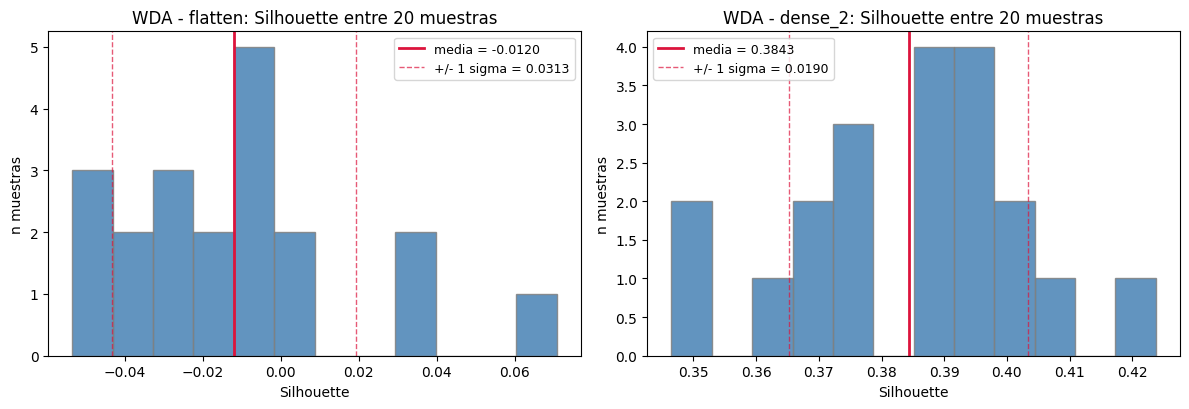

In [33]:
# Visualizacion: distribucion del Silhouette entre muestras
fig, axes = plt.subplots(1, len(CAPAS_EVAL), figsize=(6 * len(CAPAS_EVAL), 4.2))
if len(CAPAS_EVAL) == 1:
    axes = [axes]

for ax, capa in zip(axes, CAPAS_EVAL):
    sub = tabla_repr[tabla_repr["capa"] == capa]["silhouette"]
    ax.hist(sub, bins=12, color="steelblue", edgecolor="gray", alpha=0.85)
    ax.axvline(sub.mean(), color="crimson", lw=2,
               label=f"media = {sub.mean():.4f}")
    ax.axvline(sub.mean() - sub.std(), color="crimson", ls="--", lw=1, alpha=0.7)
    ax.axvline(sub.mean() + sub.std(), color="crimson", ls="--", lw=1, alpha=0.7,
               label=f"+/- 1 sigma = {sub.std():.4f}")
    ax.set_title(f"WDA - {capa}: Silhouette entre {N_SEMILLAS} muestras")
    ax.set_xlabel("Silhouette")
    ax.set_ylabel("n muestras")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Cómo leer el resultado**

- **Desviación pequeña respecto de la media** (por ejemplo, $\sigma < 10\%$ de la media):
  el resultado es una propiedad de la clase, no del subconjunto. La muestra con
  `random_state=42` es representativa y las conclusiones de `exp_wda` se generalizan.
- **Desviación grande**: el resultado depende fuertemente de qué espectros tocaron, y
  habría que reportar el intervalo en lugar de un valor puntual, o aumentar $n$.
- **$k$ del eigengap estable entre muestras**: la elección del número de clusters no es un
  artefacto del muestreo.

## Experimento 2 — Orden de PCA y estandarización

### El problema

El pipeline actual aplica PCA sobre las features crudas y estandariza **después**:

```python
flatten_32 = PCA(n_components=32).fit_transform(flatten_features)   # sin estandarizar antes
...
Xs = StandardScaler().fit_transform(features_32)                    # estandariza despues
```

Estandarizar después de PCA equivale a **whitening**: cada componente principal queda con
varianza 1. La consecuencia es que se pierde la jerarquía de varianza que PCA acababa de
construir: la primera componente y la trigésimo segunda pesan lo mismo en la distancia
euclidiana, aunque la primera pueda explicar dos órdenes de magnitud más varianza que la
última. Si las últimas componentes son mayoritariamente ruido, el whitening lo amplifica.

Existe además una **asimetría entre capas**: `dense_2` ya tiene 32 dimensiones y no pasa
por PCA, de modo que en esa capa el `StandardScaler` estandariza activaciones reales de la
red, mientras que en las otras tres blanquea componentes principales. No son la misma
operación, y eso podría explicar parte de la diferencia observada entre capas.

### Variantes comparadas

| Variante | Orden | Comentario |
|---|---|---|
| **A** | PCA → StandardScaler | El pipeline actual (whitening) |
| **B** | StandardScaler → PCA | Orden convencional: se estandarizan las features y PCA opera sobre variables comparables |
| **C** | PCA, sin estandarizar | Conserva la jerarquía de varianza de PCA |
| **D** | StandardScaler → PCA → StandardScaler | Estandariza antes y blanquea después |

Todas se evalúan con el mismo algoritmo, el mismo $k$ y las mismas métricas, de modo que
la única variable es el orden del preprocesamiento.

In [34]:
def preparar_variante(F, variante, n_comp=32, random_state=RANDOM_STATE):
    """
    Devuelve la matriz lista para clustering segun la variante de preprocesamiento.

    A: PCA -> StandardScaler          (pipeline actual, whitening)
    B: StandardScaler -> PCA          (orden convencional)
    C: PCA, sin estandarizar          (conserva jerarquia de varianza)
    D: StandardScaler -> PCA -> StandardScaler
    """
    tiene_pca = F.shape[1] > n_comp     # dense_2 ya viene en 32

    if variante == "A":
        F32 = PCA(n_components=n_comp, random_state=random_state).fit_transform(F) if tiene_pca else F.copy()
        return StandardScaler().fit_transform(F32)

    if variante == "B":
        Fs  = StandardScaler().fit_transform(F)
        return PCA(n_components=n_comp, random_state=random_state).fit_transform(Fs) if tiene_pca else Fs

    if variante == "C":
        return PCA(n_components=n_comp, random_state=random_state).fit_transform(F) if tiene_pca else F.copy()

    if variante == "D":
        Fs  = StandardScaler().fit_transform(F)
        F32 = PCA(n_components=n_comp, random_state=random_state).fit_transform(Fs) if tiene_pca else Fs
        return StandardScaler().fit_transform(F32)

    raise ValueError("variante debe ser 'A', 'B', 'C' o 'D'")


DESCRIPCION_VARIANTE = {
    "A": "PCA -> StandardScaler (actual)",
    "B": "StandardScaler -> PCA",
    "C": "PCA sin estandarizar",
    "D": "StandardScaler -> PCA -> StandardScaler",
}

In [35]:
# Muestra de referencia (la misma del experimento principal: random_state=42)
rng_ref = np.random.default_rng(RANDOM_STATE)
idx_ref = rng_ref.choice(N_POOL, size=N_MUESTRAS, replace=False)

MUESTRA_REF = {capa: F[idx_ref] for capa, F in POOL.items()}
print(f"muestra de referencia: {N_MUESTRAS} espectros")

muestra de referencia: 1100 espectros


In [36]:
# Comparacion de las cuatro variantes, en todas las capas
filas = []
for capa in ["flatten", "dense", "dense_1", "dense_2"]:
    F = MUESTRA_REF[capa]
    for variante in ["A", "B", "C", "D"]:
        Xs = preparar_variante(F, variante)

        k = K_REF[capa]
        labels = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                                    assign_labels="kmeans",
                                    random_state=RANDOM_STATE).fit_predict(Xs)
        m = compute_cluster_metrics(Xs, labels)

        filas.append({
            "capa"       : capa,
            "variante"   : variante,
            "orden"      : DESCRIPCION_VARIANTE[variante],
            "k"          : k,
            "silhouette" : m["silhouette"],
            "davies_b"   : m["davies_bouldin"],
            "calinski_h" : m["calinski_harabasz"],
        })
        print(f"  {capa:9} {variante}  sil={m['silhouette']:.4f}")

tabla_orden = pd.DataFrame(filas)
print("\n=== Efecto del orden de PCA y estandarizacion (WDA, muestra de referencia) ===")
display(tabla_orden)

  flatten   A  sil=-0.0089
  flatten   B  sil=0.1167
  flatten   C  sil=0.0311
  flatten   D  sil=-0.0442
  dense     A  sil=-0.0799
  dense     B  sil=0.0917
  dense     C  sil=0.0745
  dense     D  sil=0.0251
  dense_1   A  sil=0.1011
  dense_1   B  sil=0.3109
  dense_1   C  sil=0.3966
  dense_1   D  sil=0.1696
  dense_2   A  sil=0.3683
  dense_2   B  sil=0.3683
  dense_2   C  sil=0.3794
  dense_2   D  sil=0.3683

=== Efecto del orden de PCA y estandarizacion (WDA, muestra de referencia) ===


,capa,variante,orden,k,silhouette,davies_b,calinski_h
0,flatten,A,PCA -> StandardScaler (actual),3,-0.008927,2.826131,22.4874
1,flatten,B,StandardScaler -> PCA,3,0.116680,2.245656,12.9635
2,flatten,C,PCA sin estandarizar,3,0.031100,1.387762,7.7015
3,flatten,D,StandardScaler -> PCA -> StandardScaler,3,-0.044171,2.497191,21.3149
4,dense,A,PCA -> StandardScaler (actual),5,-0.079854,3.551834,19.8564
5,dense,B,StandardScaler -> PCA,5,0.091656,2.300921,28.5756
6,dense,C,PCA sin estandarizar,5,0.074453,2.089060,13.0503
7,dense,D,StandardScaler -> PCA -> StandardScaler,5,0.025106,2.639260,25.9121
8,dense_1,A,PCA -> StandardScaler (actual),2,0.101142,4.905816,25.8327
9,dense_1,B,StandardScaler -> PCA,2,0.310891,1.417434,96.3970


In [37]:
# Tabla pivote: Silhouette por capa y variante
pivote = tabla_orden.pivot(index="capa", columns="variante", values="silhouette")
pivote = pivote.loc[["flatten", "dense", "dense_1", "dense_2"]]
print("=== Silhouette por capa y variante de preprocesamiento ===")
display(pivote.round(4))

print("\nMejor variante por capa:")
for capa in pivote.index:
    mejor = pivote.loc[capa].idxmax()
    print(f"  {capa:9} -> {mejor}  ({DESCRIPCION_VARIANTE[mejor]}), sil = {pivote.loc[capa, mejor]:.4f}")

=== Silhouette por capa y variante de preprocesamiento ===


variante,A,B,C,D
capa,,,,
flatten,-0.0089,0.1167,0.0311,-0.0442
dense,-0.0799,0.0917,0.0745,0.0251
dense_1,0.1011,0.3109,0.3966,0.1696
dense_2,0.3683,0.3683,0.3794,0.3683



Mejor variante por capa:
  flatten   -> B  (StandardScaler -> PCA), sil = 0.1167
  dense     -> B  (StandardScaler -> PCA), sil = 0.0917
  dense_1   -> C  (PCA sin estandarizar), sil = 0.3966
  dense_2   -> C  (PCA sin estandarizar), sil = 0.3794


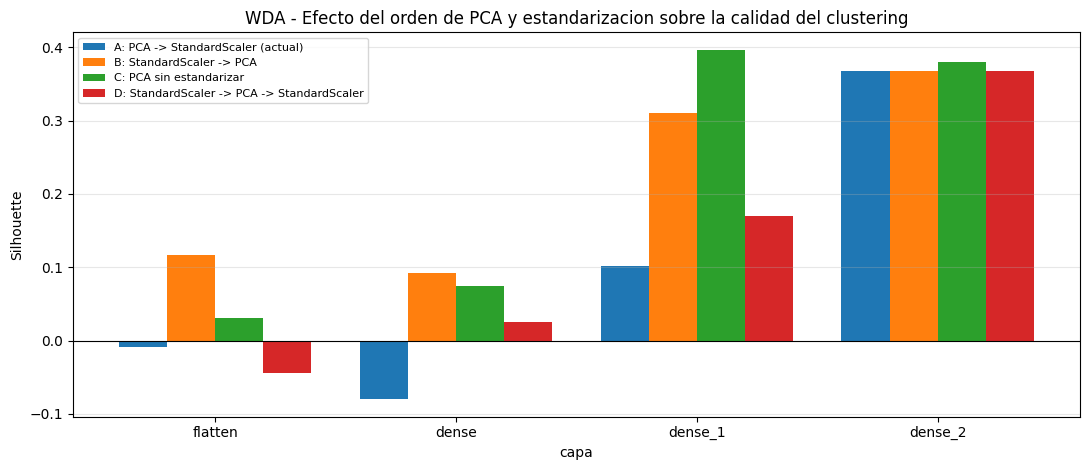

In [38]:
# Visualizacion comparativa
capas = ["flatten", "dense", "dense_1", "dense_2"]
variantes = ["A", "B", "C", "D"]
x = np.arange(len(capas))
ancho = 0.2

plt.figure(figsize=(11, 4.8))
for i, v in enumerate(variantes):
    vals = [tabla_orden[(tabla_orden.capa == c) & (tabla_orden.variante == v)]["silhouette"].values[0]
            for c in capas]
    plt.bar(x + (i - 1.5) * ancho, vals, ancho, label=f"{v}: {DESCRIPCION_VARIANTE[v]}")

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, capas)
plt.xlabel("capa")
plt.ylabel("Silhouette")
plt.title("WDA - Efecto del orden de PCA y estandarizacion sobre la calidad del clustering")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Varianza explicada: cuanto se pierde al blanquear
print("=== Varianza explicada por las 32 componentes principales (muestra de referencia) ===")
for capa in ["flatten", "dense", "dense_1"]:
    F = MUESTRA_REF[capa]
    pca = PCA(n_components=32, random_state=RANDOM_STATE).fit(F)
    vr  = pca.explained_variance_ratio_
    print(f"\n  {capa}:")
    print(f"     total explicada por 32 PCs : {vr.sum():.4f}")
    print(f"     PC1                        : {vr[0]:.4f}")
    print(f"     PC32                       : {vr[-1]:.6f}")
    print(f"     razon PC1/PC32             : {vr[0]/vr[-1]:.1f}x")
    print(f"     -> tras el whitening ambas pesan igual en la distancia euclidiana")

=== Varianza explicada por las 32 componentes principales (muestra de referencia) ===

  flatten:
     total explicada por 32 PCs : 0.9989
     PC1                        : 0.9731
     PC32                       : 0.000045
     razon PC1/PC32             : 21417.1x
     -> tras el whitening ambas pesan igual en la distancia euclidiana

  dense:
     total explicada por 32 PCs : 0.9971
     PC1                        : 0.8308
     PC32                       : 0.000224
     razon PC1/PC32             : 3717.3x
     -> tras el whitening ambas pesan igual en la distancia euclidiana

  dense_1:
     total explicada por 32 PCs : 0.9997
     PC1                        : 0.8832
     PC32                       : 0.000028
     razon PC1/PC32             : 31315.1x
     -> tras el whitening ambas pesan igual en la distancia euclidiana


**Cómo leer el resultado**

La razón PC1/PC32 indica cuánta jerarquía de varianza destruye el whitening. Si es de
varios órdenes de magnitud, la variante A está dando el mismo peso a una dirección
dominante y a una que es esencialmente ruido.

Tres desenlaces posibles:

- **A gana o empata**: el orden actual está justificado empíricamente. Se documenta en la
  memoria que la elección fue verificada, y que el whitening no perjudica.
- **B o D ganan claramente**: conviene corregir el pipeline. Es un cambio de dos líneas en
  `reduce_all_to_32()`, aunque obliga a recalcular los resultados de las tablas.
- **C gana**: la jerarquía de varianza de PCA era informativa y no debía normalizarse.

En cualquier caso, el resultado se reporta: una decisión de preprocesamiento verificada
vale más que una asumida.

## Experimento 3 — ¿Son las mismas subclases?

Los experimentos anteriores verifican que las **métricas** se mantienen estables entre
muestras. Eso es necesario, pero no suficiente para el objetivo de este trabajo: dos
muestras podrían alcanzar el mismo Silhouette y sin embargo estar dividiendo la clase por
ejes físicos distintos. La pregunta que importa es si **reaparecen los mismos grupos**.

### Cómo se mide

Para cada muestra se calcula el **espectro promedio de cada cluster**, y los clusters de
muestras distintas se emparejan entre sí. La comparación no se hace sobre los espectros
promedio directos, sino sobre los **espectros de diferencia** respecto del promedio global
de la clase:

$$ d_i = \overline{x}_{\text{cluster } i} - \overline{x}_{\text{clase}} $$

La razón es que todos los espectros de enanas blancas de una misma clase se parecen mucho
entre sí, de modo que la correlación entre promedios crudos sería cercana a 1 en cualquier
caso y no discriminaría nada. El espectro de diferencia aísla justamente **lo que hace
distintivo a cada cluster**, que es lo que define una subclase.

El emparejamiento entre particiones se resuelve de forma óptima con el algoritmo húngaro
(`linear_sum_assignment`), maximizando la correlación total, en lugar de asumir que el
cluster 0 de una muestra corresponde al cluster 0 de otra: las etiquetas que asignan los
algoritmos son arbitrarias.

In [40]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


def espectros_promedio_por_cluster(spectra, labels):
    """Espectro promedio de cada cluster (se excluye el ruido -1)."""
    etiquetas = sorted(int(l) for l in np.unique(labels) if l != -1)
    M = np.vstack([spectra[labels == l].mean(axis=0) for l in etiquetas])
    return M, etiquetas


def emparejar_particiones(D_ref, D_test):
    """
    Empareja de forma optima los clusters de dos particiones, maximizando la
    correlacion entre sus espectros de diferencia (algoritmo hungaro).

    D_ref, D_test : matrices (k, n_puntos) de espectros de DIFERENCIA
    Devuelve lista de tuplas (i_ref, j_test, correlacion).
    """
    k_ref, k_test = D_ref.shape[0], D_test.shape[0]

    C = np.zeros((k_ref, k_test))
    for i in range(k_ref):
        for j in range(k_test):
            C[i, j] = np.corrcoef(D_ref[i], D_test[j])[0, 1]

    filas, cols = linear_sum_assignment(-C)      # -C para maximizar
    return [(int(i), int(j), float(C[i, j])) for i, j in zip(filas, cols)]


def experimento_mismas_subclases(pool, spectra_pool, capa, k_ref,
                                 n_muestras=1100, n_semillas=20,
                                 semilla_base=42, umbral_corr=0.90):
    """
    Verifica si los mismos grupos reaparecen en muestras independientes.

    Para cada muestra: clusteriza, calcula el espectro promedio de cada cluster y su
    espectro de diferencia respecto del promedio global de la muestra. Luego empareja
    cada particion con la de la muestra de referencia (la primera semilla) y reporta
    la correlacion de los pares emparejados.
    """
    F_pool  = pool[capa]
    n_total = F_pool.shape[0]

    D_ref = None
    filas = []

    for s in range(n_semillas):
        semilla = semilla_base + s
        rng = np.random.default_rng(semilla)
        idx = rng.choice(n_total, size=n_muestras, replace=False)

        F  = F_pool[idx]
        F32 = (PCA(n_components=32, random_state=RANDOM_STATE).fit_transform(F)
               if F.shape[1] > 32 else F.copy())
        Xs = StandardScaler().fit_transform(F32)

        labels = SpectralClustering(n_clusters=k_ref, affinity="nearest_neighbors",
                                    assign_labels="kmeans",
                                    random_state=RANDOM_STATE).fit_predict(Xs)

        S = spectra_pool[idx]
        M, etiquetas = espectros_promedio_por_cluster(S, labels)
        D = M - S.mean(axis=0)               # espectros de diferencia

        if D_ref is None:                     # la primera semilla es la referencia
            D_ref = D
            print(f"  semilla {semilla}: REFERENCIA ({len(etiquetas)} clusters, "
                  f"tamanos {[int(np.sum(labels==l)) for l in etiquetas]})")
            continue

        pares = emparejar_particiones(D_ref, D)
        for i_ref, j_test, corr in pares:
            rms = float(np.sqrt(np.mean((D_ref[i_ref] - D[j_test]) ** 2)))
            filas.append({
                "semilla"        : semilla,
                "cluster_ref"    : i_ref,
                "cluster_test"   : j_test,
                "correlacion"    : round(corr, 4),
                "rms_diferencia" : round(rms, 5),
                "recuperado"     : corr >= umbral_corr
            })
        peor = min(c for _, _, c in pares)
        print(f"  semilla {semilla}: correlacion minima entre pares = {peor:.4f}")

    return pd.DataFrame(filas), D_ref

In [41]:
# Ejecucion del experimento 3
CAPA_SUBCLASES = "dense_2"        # capa con mejor estructura en la Parte I
K_SUBCLASES    = K_REF[CAPA_SUBCLASES]

print(f"=== Capa {CAPA_SUBCLASES}, k = {K_SUBCLASES} ===")
tabla_subclases, D_referencia = experimento_mismas_subclases(
    POOL, X_pool_spec, CAPA_SUBCLASES, K_SUBCLASES,
    n_muestras=N_MUESTRAS, n_semillas=N_SEMILLAS
)

print()
display(tabla_subclases.head(10))

=== Capa dense_2, k = 2 ===
  semilla 42: REFERENCIA (2 clusters, tamanos [600, 500])
  semilla 43: correlacion minima entre pares = 0.9631
  semilla 44: correlacion minima entre pares = 0.9649
  semilla 45: correlacion minima entre pares = 0.9702
  semilla 46: correlacion minima entre pares = 0.9608
  semilla 47: correlacion minima entre pares = 0.9664
  semilla 48: correlacion minima entre pares = 0.9909
  semilla 49: correlacion minima entre pares = 0.9697
  semilla 50: correlacion minima entre pares = 0.9704
  semilla 51: correlacion minima entre pares = 0.9713
  semilla 52: correlacion minima entre pares = 0.9732
  semilla 53: correlacion minima entre pares = 0.9661
  semilla 54: correlacion minima entre pares = 0.9726
  semilla 55: correlacion minima entre pares = 0.9709
  semilla 56: correlacion minima entre pares = 0.9731
  semilla 57: correlacion minima entre pares = 0.9704
  semilla 58: correlacion minima entre pares = 0.9720
  semilla 59: correlacion minima entre pares = 0.9

,semilla,cluster_ref,cluster_test,correlacion,rms_diferencia,recuperado
0,43,0,0,0.9631,0.13882,True
1,43,1,1,0.9631,0.11426,True
2,44,0,1,0.9649,0.08104,True
3,44,1,0,0.9649,0.09205,True
4,45,0,0,0.9702,0.09549,True
5,45,1,1,0.9702,0.07184,True
6,46,0,1,0.9608,0.14056,True
7,46,1,0,0.9608,0.12459,True
8,47,0,1,0.9664,0.07840,True
9,47,1,0,0.9664,0.07993,True


In [42]:
# Resumen: con que frecuencia reaparece cada cluster de la referencia
resumen_subclases = (tabla_subclases
                     .groupby("cluster_ref")
                     .agg(n_comparaciones = ("semilla", "count"),
                          corr_media      = ("correlacion", "mean"),
                          corr_min        = ("correlacion", "min"),
                          rms_medio       = ("rms_diferencia", "mean"),
                          n_recuperado    = ("recuperado", "sum"))
                     .reset_index())
resumen_subclases["pct_recuperado"] = (100 * resumen_subclases["n_recuperado"]
                                       / resumen_subclases["n_comparaciones"]).round(1)

print("=== Reaparicion de cada subclase en muestras independientes ===")
display(resumen_subclases.round(4))

print("\nLectura para la memoria:")
for _, r in resumen_subclases.iterrows():
    print(f"  El cluster {int(r['cluster_ref'])} reaparece en "
          f"{int(r['n_recuperado'])} de {int(r['n_comparaciones'])} muestras "
          f"({r['pct_recuperado']:.0f}%), con correlacion media "
          f"{r['corr_media']:.4f} entre sus espectros de diferencia")

=== Reaparicion de cada subclase en muestras independientes ===


,cluster_ref,n_comparaciones,corr_media,corr_min,rms_medio,n_recuperado,pct_recuperado
0,0,19,0.9692,0.9499,0.1031,19,100.0
1,1,19,0.9692,0.9499,0.0889,19,100.0



Lectura para la memoria:
  El cluster 0 reaparece en 19 de 19 muestras (100%), con correlacion media 0.9692 entre sus espectros de diferencia
  El cluster 1 reaparece en 19 de 19 muestras (100%), con correlacion media 0.9692 entre sus espectros de diferencia


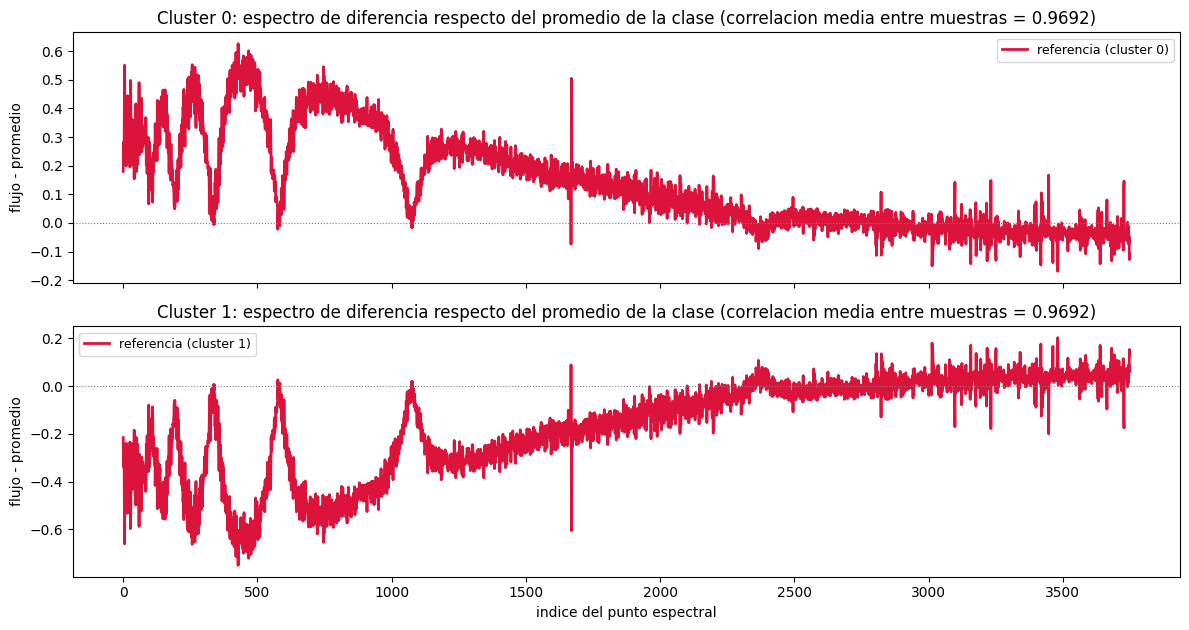

In [43]:
# Visualizacion: espectros de diferencia de la referencia vs los de otras muestras
fig, axes = plt.subplots(len(D_referencia), 1,
                         figsize=(12, 3.2 * len(D_referencia)), sharex=True)
if len(D_referencia) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(D_referencia[i], color="crimson", lw=2, label=f"referencia (cluster {i})")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    sub = tabla_subclases[tabla_subclases["cluster_ref"] == i]
    ax.set_title(f"Cluster {i}: espectro de diferencia respecto del promedio de la clase "
                 f"(correlacion media entre muestras = {sub['correlacion'].mean():.4f})")
    ax.set_ylabel("flujo - promedio")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("indice del punto espectral")
plt.tight_layout()
plt.show()

**Cómo leer el resultado**

- **Correlación media alta (> 0,9) y porcentaje de recuperación alto**: la subclase no es
  un accidente del muestreo. El mismo patrón espectral reaparece al cambiar los espectros,
  de modo que corresponde a una división real de la clase WDA.
- **Correlación baja o errática**: los grupos que se forman dependen de qué espectros
  tocaron, y no puede afirmarse que definan una subclase.

Nótese que este criterio es **astrofísico y no métrico**: no compara números de calidad de
agrupamiento, sino los espectros mismos, que es el objeto de estudio del trabajo.

## Experimento 4 — Extensión de la partición al resto de la clase

Este experimento responde directamente la pregunta de fondo: **si una subclase se
encuentra en la muestra de 1.100, ¿existe también en el resto de los 13.723 espectros?**

### La idea

En lugar de repetir el clustering sobre la clase completa (costoso: DBCV es $O(n^2)$ y
requeriría del orden de 7 GB, y la descomposición espectral densa implica $2{,}6\times
10^{12}$ operaciones), se hace lo inverso y mucho más barato:

1. Se ajustan PCA y `StandardScaler` **sobre la muestra de 1.100** y se clusteriza.
2. Se calculan los **centroides** de los clusters en ese espacio de 32 dimensiones.
3. Se proyectan los **13.723 espectros** con la *misma* transformación, usando
   `transform()` y no `fit_transform()`, de modo que el espacio no cambia.
4. Cada espectro del pool se asigna al centroide más cercano.
5. Se comparan los espectros promedio de los grupos así extendidos con los de la muestra
   original.

Este procedimiento sólo es posible porque **PCA proporciona un mapeo explícito y
reutilizable**, a diferencia de t-SNE. Es exactamente la propiedad que se discutió en el
Capítulo 3 al justificar el uso de PCA para la reducción y de t-SNE sólo para
visualización.

### Qué demuestra

Si los espectros promedio de los grupos extendidos coinciden con los originales, la
estructura hallada en la muestra **describe a la clase completa** y no sólo al subconjunto.
Es la evidencia que permite afirmar que las subclases identificadas son de WDA como clase,
no de las 1.100 muestras.

In [44]:
def extender_particion(pool_features, spectra_pool, capa, k,
                       idx_muestra=None, n_muestras=1100, semilla=42):
    """
    Ajusta el pipeline en una muestra, y extiende su particion a TODO el pool
    asignando cada espectro al centroide mas cercano.

    Devuelve un dict con las etiquetas de la muestra, las del pool completo y los
    espectros promedio de ambos, listos para comparar.
    """
    F_pool = pool_features[capa]
    n_total = F_pool.shape[0]

    if idx_muestra is None:
        rng = np.random.default_rng(semilla)
        idx_muestra = rng.choice(n_total, size=n_muestras, replace=False)

    F_m = F_pool[idx_muestra]

    # --- ajuste del pipeline SOLO con la muestra ---
    if F_m.shape[1] > 32:
        pca = PCA(n_components=32, random_state=RANDOM_STATE).fit(F_m)
        proy = lambda A: pca.transform(A)
    else:
        proy = lambda A: A                      # dense_2 ya viene en 32

    scaler = StandardScaler().fit(proy(F_m))

    Xs_muestra = scaler.transform(proy(F_m))
    labels_m = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                                  assign_labels="kmeans",
                                  random_state=RANDOM_STATE).fit_predict(Xs_muestra)

    # --- centroides de la muestra ---
    etiquetas  = sorted(int(l) for l in np.unique(labels_m) if l != -1)
    centroides = np.vstack([Xs_muestra[labels_m == l].mean(axis=0) for l in etiquetas])

    # --- proyeccion del POOL COMPLETO con la MISMA transformacion ---
    Xs_pool = scaler.transform(proy(F_pool))    # transform, no fit_transform

    # --- asignacion al centroide mas cercano ---
    d = cdist(Xs_pool, centroides)
    labels_pool = np.array([etiquetas[j] for j in np.argmin(d, axis=1)])

    # --- espectros promedio de ambos conjuntos ---
    S_m = spectra_pool[idx_muestra]
    M_muestra, _ = espectros_promedio_por_cluster(S_m, labels_m)
    M_pool,    _ = espectros_promedio_por_cluster(spectra_pool, labels_pool)

    return {
        "idx_muestra"  : idx_muestra,
        "labels_muestra": labels_m,
        "labels_pool"  : labels_pool,
        "etiquetas"    : etiquetas,
        "M_muestra"    : M_muestra,
        "M_pool"       : M_pool,
        "media_muestra": S_m.mean(axis=0),
        "media_pool"   : spectra_pool.mean(axis=0),
    }

In [45]:
# Ejecucion del experimento 4
ext = extender_particion(POOL, X_pool_spec, CAPA_SUBCLASES, K_SUBCLASES,
                         n_muestras=N_MUESTRAS, semilla=RANDOM_STATE)

print(f"=== Extension de la particion de {N_MUESTRAS} espectros a los {N_POOL} de la clase ===")
print(f"capa {CAPA_SUBCLASES}, k = {K_SUBCLASES}\n")

filas = []
for i, lab in enumerate(ext["etiquetas"]):
    n_m = int(np.sum(ext["labels_muestra"] == lab))
    n_p = int(np.sum(ext["labels_pool"] == lab))

    d_m = ext["M_muestra"][i] - ext["media_muestra"]
    d_p = ext["M_pool"][i]    - ext["media_pool"]

    corr = float(np.corrcoef(d_m, d_p)[0, 1])
    rms  = float(np.sqrt(np.mean((d_m - d_p) ** 2)))

    filas.append({
        "cluster"          : lab,
        "n_en_muestra"     : n_m,
        "pct_muestra"      : round(100 * n_m / len(ext["labels_muestra"]), 1),
        "n_en_clase"       : n_p,
        "pct_clase"        : round(100 * n_p / len(ext["labels_pool"]), 1),
        "corr_espectros"   : round(corr, 4),
        "rms_diferencia"   : round(rms, 5),
    })

tabla_extension = pd.DataFrame(filas)
display(tabla_extension)

print("\nLectura:")
for _, r in tabla_extension.iterrows():
    print(f"  Cluster {int(r['cluster'])}: {r['pct_muestra']:.1f}% de la muestra -> "
          f"{r['pct_clase']:.1f}% de la clase | correlacion de espectros = {r['corr_espectros']:.4f}")

=== Extension de la particion de 1100 espectros a los 13711 de la clase ===
capa dense_2, k = 2



,cluster,n_en_muestra,pct_muestra,n_en_clase,pct_clase,corr_espectros,rms_diferencia
0,0,600,54.5,6934,50.6,0.9612,0.13415
1,1,500,45.5,6777,49.4,0.9612,0.17377



Lectura:
  Cluster 0: 54.5% de la muestra -> 50.6% de la clase | correlacion de espectros = 0.9612
  Cluster 1: 45.5% de la muestra -> 49.4% de la clase | correlacion de espectros = 0.9612


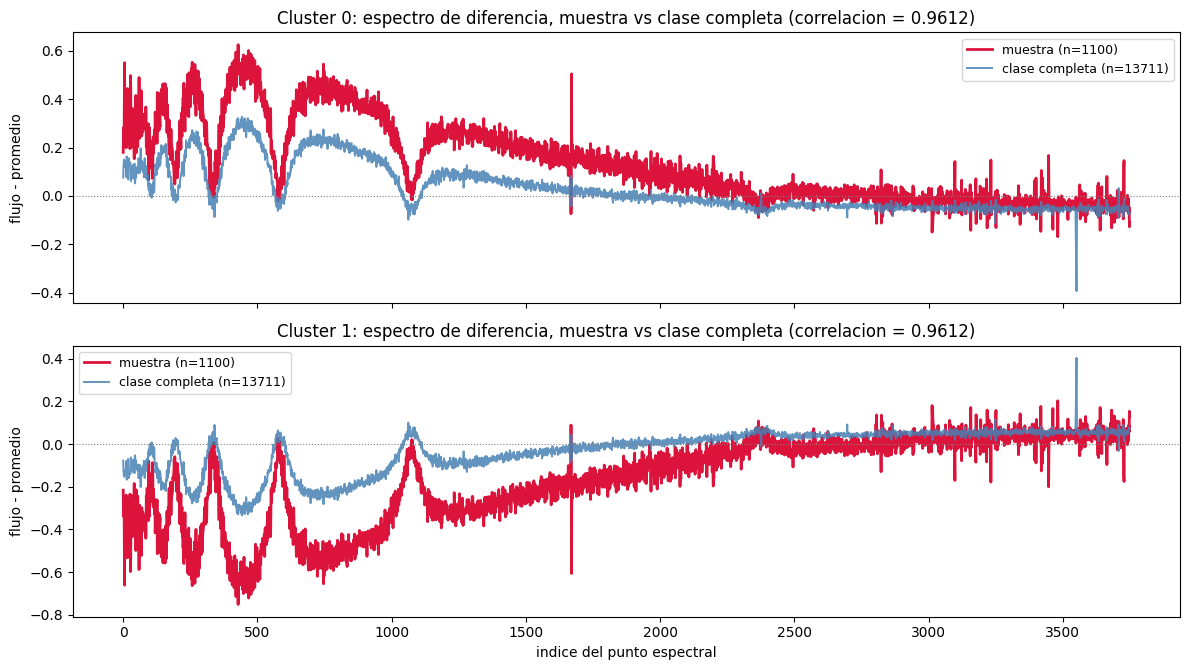

In [46]:
# Comparacion visual: espectro de diferencia en la muestra vs en la clase completa
n_cl = len(ext["etiquetas"])
fig, axes = plt.subplots(n_cl, 1, figsize=(12, 3.4 * n_cl), sharex=True)
if n_cl == 1:
    axes = [axes]

for i, (ax, lab) in enumerate(zip(axes, ext["etiquetas"])):
    d_m = ext["M_muestra"][i] - ext["media_muestra"]
    d_p = ext["M_pool"][i]    - ext["media_pool"]

    ax.plot(d_m, color="crimson",   lw=2.0, label=f"muestra (n={N_MUESTRAS})")
    ax.plot(d_p, color="steelblue", lw=1.4, alpha=0.85,
            label=f"clase completa (n={N_POOL})")
    ax.axhline(0, color="gray", lw=0.8, ls=":")

    corr = np.corrcoef(d_m, d_p)[0, 1]
    ax.set_title(f"Cluster {lab}: espectro de diferencia, muestra vs clase completa "
                 f"(correlacion = {corr:.4f})")
    ax.set_ylabel("flujo - promedio")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("indice del punto espectral")
plt.tight_layout()
plt.show()

**Cómo leer el resultado**

- **Correlación alta y proporciones similares** (por ejemplo, un cluster que agrupa el 30%
  de la muestra agrupa también cerca del 30% de la clase): la partición se extiende de
  forma natural. La subclase es una propiedad de WDA, no del subconjunto, y **no hace falta
  reclusterizar los 13.723 espectros** para afirmarlo.
- **Correlación baja o proporciones muy distintas**: la estructura hallada no se generaliza,
  y habría que revisar el tamaño de muestra.

Este experimento convierte la limitación de recursos en una decisión metodológica
respaldada: en lugar de repetir un clustering costoso sobre la clase completa, se verifica
que la partición aprendida en la muestra describe correctamente a la clase completa.

## Resumen para la memoria

In [47]:
print("=" * 78)
print("EXPERIMENTO 1 - REPRESENTATIVIDAD DE LA MUESTRA")
print("=" * 78)
for _, r in resumen_repr.iterrows():
    cv = 100 * r["sil_std"] / abs(r["sil_media"]) if r["sil_media"] else float("nan")
    print(f"  {r['capa']:9} Silhouette = {r['sil_media']:.4f} +/- {r['sil_std']:.4f}  "
          f"(variacion relativa {cv:.1f}%)")

print()
print("=" * 78)
print("EXPERIMENTO 2 - ORDEN DE PCA Y ESTANDARIZACION")
print("=" * 78)
for capa in pivote.index:
    mejor  = pivote.loc[capa].idxmax()
    actual = pivote.loc[capa, "A"]
    dif    = pivote.loc[capa, mejor] - actual
    estado = "el orden actual es el mejor" if mejor == "A" else f"mejora {dif:+.4f} con la variante {mejor}"
    print(f"  {capa:9} actual (A) = {actual:.4f}  |  {estado}")

print()
print("=" * 78)
print("EXPERIMENTO 3 - LAS MISMAS SUBCLASES REAPARECEN")
print("=" * 78)
for _, r in resumen_subclases.iterrows():
    print(f"  Cluster {int(r['cluster_ref'])}: reaparece en {r['pct_recuperado']:.0f}% de las "
          f"muestras | correlacion media = {r['corr_media']:.4f}")

print()
print("=" * 78)
print("EXPERIMENTO 4 - LA PARTICION SE EXTIENDE A LA CLASE COMPLETA")
print("=" * 78)
for _, r in tabla_extension.iterrows():
    print(f"  Cluster {int(r['cluster'])}: {r['pct_muestra']:5.1f}% de la muestra -> "
          f"{r['pct_clase']:5.1f}% de la clase | correlacion = {r['corr_espectros']:.4f}")

EXPERIMENTO 1 - REPRESENTATIVIDAD DE LA MUESTRA
  dense_2   Silhouette = 0.3843 +/- 0.0190  (variacion relativa 4.9%)
  flatten   Silhouette = -0.0120 +/- 0.0313  (variacion relativa 260.8%)

EXPERIMENTO 2 - ORDEN DE PCA Y ESTANDARIZACION
  flatten   actual (A) = -0.0089  |  mejora +0.1256 con la variante B
  dense     actual (A) = -0.0799  |  mejora +0.1715 con la variante B
  dense_1   actual (A) = 0.1011  |  mejora +0.2955 con la variante C
  dense_2   actual (A) = 0.3683  |  mejora +0.0111 con la variante C

EXPERIMENTO 3 - LAS MISMAS SUBCLASES REAPARECEN
  Cluster 0: reaparece en 100% de las muestras | correlacion media = 0.9692
  Cluster 1: reaparece en 100% de las muestras | correlacion media = 0.9692

EXPERIMENTO 4 - LA PARTICION SE EXTIENDE A LA CLASE COMPLETA
  Cluster 0:  54.5% de la muestra ->  50.6% de la clase | correlacion = 0.9612
  Cluster 1:  45.5% de la muestra ->  49.4% de la clase | correlacion = 0.9612


### Dónde va cada resultado

- **Experimento 1** → Capítulo 6, como respaldo de la Sección de datos utilizados y de las
  tablas de resultados de WDA: permite reportar las métricas como media ± desviación sobre
  muestras independientes, en lugar de un valor puntual. También refuerza la Sección de
  controles de robustez.
- **Experimento 2** → Capítulo 6, Sección de reducción de dimensionalidad: documenta que el
  orden del preprocesamiento fue verificado y no simplemente heredado.

### Nota sobre las otras clases

Este cuaderno se centra en WDA porque es la única clase donde la muestra es un subconjunto
pequeño de la población: se usan 1.100 de 13.723 espectros, un 8%. En WDB se emplean 1.100
de aproximadamente 1.180 disponibles (93%) y en WD se utilizan todos los espectros válidos,
de modo que en esas dos clases la muestra prácticamente coincide con la clase completa y la
pregunta de representatividad no se plantea en los mismos términos.